<a href="https://colab.research.google.com/github/rll/deepul/blob/master/homeworks/hw4/hw4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Getting Started

## Overview
This semester, all homeworks will be conducted through Google Colab notebooks. All code for the homework assignment will be written and run in this notebook. Running in Colab will automatically provide a GPU, but you may also run this notebook locally by following [these instructions](https://research.google.com/colaboratory/local-runtimes.html) if you wish to use your own GPU.

You will save images in the notebooks to use and fill out a given LaTeX template which will be submitted to Gradescope, along with your notebook code.

## Using Colab
On the left-hand side, you can click the different icons to see a Table of Contents of the assignment, as well as local files accessible through the notebook.

Make sure to go to **Runtime -> Change runtime type** and select **GPU** as the hardware accelerator. This allows you to use a GPU. Run the cells below to get started on the assignment. Note that a session is open for a maximum of 12 hours, and using too much GPU compute may result in restricted access for a short period of time. Please start the homework early so you have ample time to work.

**If you loaded this notebook from clicking "Open in Colab" from github, you will need to save it to your own Google Drive to keep your work.**

## General Tips
In each homework problem, you will implement and train various diffusion models.

Feel free to print whatever output (e.g. debugging code, training code, etc) you want, as the graded submission will be the submitted pdf with images.

After you complete the assignment, download all of the images outputted in the results/ folder and upload them to the figure folder in the given latex template.

Run the cells below to download and load up the starter code.

In [1]:
# !if [ -d deepul ]; then rm -Rf deepul; fi
# !git clone https://github.com/rll/deepul.git
# !pip install ./deepul
# !pip install scikit-learn

In [2]:
from deepul.hw4_helper import *
import warnings
warnings.filterwarnings('ignore')
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "6"



# Question 1: Toy Dataset [30pt]

In this question, we will train a simple diffusion models a toy 2D dataset.

Execute the cell below to visualize our datasets.

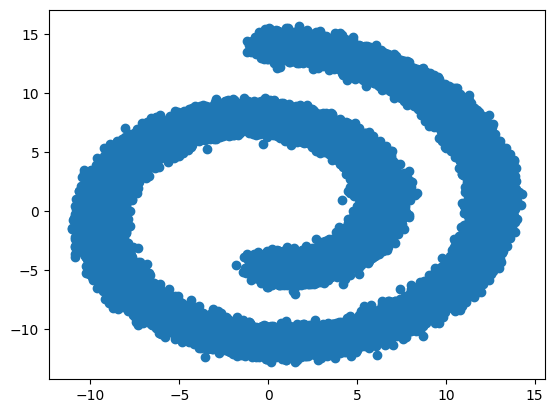

In [3]:
visualize_q1_dataset()

For code simplicity, we will train a continuous-time variant of the diffusion prompt. In practice training objectives and code between discrete-time and continuous-time diffusion models are similar.

Given a data element $x$ and neural net $f_\theta(x, t)$, implement the following diffusion training steps:
1. Sample the diffusion timestep: $t \sim \text{Uniform}(0, 1)$
2. Compute the noise-strength following a cosine schedule: $\alpha_t = \cos\left(\frac{\pi}{2}t\right), \sigma_t = \sin\left(\frac{\pi}{2}t\right)$
3. Apply the forward process - Sample noise $\epsilon \sim N(0,I)$ (same shape as $x$) and compute noised $x_t = \alpha_t x + \sigma_t \epsilon$
4. Estimate $\hat{\epsilon} = f_\theta(x_t, t)$
5. Optimize the loss $L = \lVert \epsilon - \hat{\epsilon} \rVert_2^2$. Here, it suffices to just take the mean over all dimensions.

Note that for the case of continuous-time diffusion, the forward process is $x_{0\to1}$ and reverse process is $x_{1\to0}$

Use an MLP for $f_\theta$ to optimize the loss. You may find the following details helpful.
* Normalize the data using mean and std computed from the train dataset
* Train 100 epochs, batch size 1024, Adam with LR 1e-3 (100 warmup steps, cosine decay to 0)
* MLP with 4 hidden layers and hidden size 64
* Condition on t by concatenating it with input x (i.e. 2D x + 1D t = 3D cat(x, t))

To sample, implement the standard DDPM sampler. You may find the equation from the [DDIM paper](https://arxiv.org/pdf/2010.02502.pdf) helpful, rewritten and re-formatted here for convenience.
$$x_{t-1} = \alpha_{t-1}\left(\frac{x_t - \sigma_t\hat{\epsilon}}{\alpha_t}\right) + \sqrt{\sigma_{t-1}^2 - \eta_t^2}\hat{\epsilon} + \eta_t\epsilon_t$$
where $\epsilon_t \sim N(0, I)$ is random Gaussian noise. For DDPM, let
$$\eta_t = \sigma_{t-1}/\sigma_t\sqrt{1 - \alpha_t^2/\alpha_{t-1}^2}$$
To run the reverse process, start from $x_1 \sim N(0, I)$ and perform `num_steps` DDPM updates (a hyperparameter), pseudocode below.
```
ts = linspace(1 - 1e-4, 1e-4, num_steps + 1)
x = sample_normal
for i in range(num_steps):
    t = ts[i]
    tm1 = ts[i + 1]
    eps_hat = model(x, t)
    x = DDPM_UPDATE(x, eps_hat, t, tm1)
return x
```
Note: If you encounter NaNs, you may need to clip $\sigma_{t-1}^2 - \eta_t^2$ to 0 if it goes negative, as machine precision issues can make it a very small negative number (e.g. -1e-12) if its too close to 0

In [4]:
from torch.optim.lr_scheduler import LambdaLR
from torch.optim import Optimizer

import math
def get_cosine_schedule_with_warmup(
    optimizer:Optimizer, num_warmup_steps: int, num_training_steps: int, num_cycles: float = 0.5, last_epoch: int = -1
):
    """
    Create a schedule with a learning rate that decreases following the values of the cosine function between the
    initial lr set in the optimizer to 0, after a warmup period during which it increases linearly between 0 and the
    initial lr set in the optimizer.

    Args:
        optimizer ([`~torch.optim.Optimizer`]):
            The optimizer for which to schedule the learning rate.
        num_warmup_steps (`int`):
            The number of steps for the warmup phase.
        num_training_steps (`int`):
            The total number of training steps.
        num_cycles (`float`, *optional*, defaults to 0.5):
            The number of waves in the cosine schedule (the defaults is to just decrease from the max value to 0
            following a half-cosine).
        last_epoch (`int`, *optional*, defaults to -1):
            The index of the last epoch when resuming training.

    Return:
        `torch.optim.lr_scheduler.LambdaLR` with the appropriate schedule.
    """

    def lr_lambda(current_step):
        if current_step < num_warmup_steps:
            return float(current_step) / float(max(1, num_warmup_steps))
        progress = float(current_step - num_warmup_steps) / float(max(1, num_training_steps - num_warmup_steps))
        return max(0.0, 0.5 * (1.0 + math.cos(math.pi * float(num_cycles) * 2.0 * progress)))

    return LambdaLR(optimizer, lr_lambda, last_epoch)

In [5]:

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data
import math
from torch.utils.data import DataLoader

class net(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.fc1 = nn.Linear(3, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, hidden_size)
        self.fc4 = nn.Linear(hidden_size, 2)

    def forward(self, x,t):
        x = torch.cat((x,t),-1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        out = self.fc4(x)
        return out
    
class Trainner():
    def __init__(self, model, device, train_loader, test_loader, epochs,learning_rate,warmup_steps):
         
         self.model = model
         self.model.to(device)
         self.device = device
         self.train_loader = train_loader
         self.test_loader = test_loader 
         self.epochs = epochs
         self.lr = learning_rate
         
         self.optimizer = torch.optim.Adam(self.model.parameters(), lr=learning_rate)
         self.schedular = get_cosine_schedule_with_warmup(self.optimizer, num_warmup_steps = warmup_steps, num_training_steps = epochs * len(train_loader))
         self.train_losses = []
         self.test_losses = []
        
    def alpha(self,t):
        return torch.cos((math.pi/2)*t)
    
    def sigma(self,t):
        return torch.sin((math.pi/2)*t)
     
    def train(self):
        
        for epoch in range(self.epochs):
            total_loss = []
            total_val_loss = []
            
            self.model.train(True)
            
            for batch in self.train_loader:
                x = batch.to(self.device)
                
                batch_size = x.shape[0]
                
                t = torch.FloatTensor(batch_size).uniform_(0,1).reshape(-1,1).to(self.device) # (batch_size)
                eps = torch.randn_like(x).to(self.device)
                # add noise
                x_t = self.alpha(t) * x + self.sigma(t) * eps
                pred_eps = self.model(x_t, t)
                
                L = F.mse_loss(pred_eps, eps)
                
                self.optimizer.zero_grad()
                
                L.backward()
                self.optimizer.step()
                self.schedular.step()
                
                total_loss.append(L.item())
            # eval
            self.model.eval()
            with torch.no_grad():
                for val_batch in self.test_loader:
                    x = val_batch.to(self.device)
                    batch_size = x.shape[0]
                    
                    t = torch.FloatTensor(batch_size).uniform_(0,1).reshape(-1,1).to(self.device) # (batch_size)
                    eps = torch.randn_like(x).to(self.device)
                    
                    x_t = self.alpha(t) * x + self.sigma(t) * eps
                    
                    pred_eps = self.model(x_t, t)
                    
                    L = F.mse_loss(pred_eps, eps)
                    
                    total_val_loss.append(L.item())
            train_loss = np.mean(total_loss)
            test_loss = np.mean(total_val_loss)
            
            self.train_losses.append(train_loss)
            self.test_losses.append(test_loss)
            if epoch % 10 ==0:
                print(f"Epoch {epoch}; train Loss {train_loss}; val loss {test_loss}; lr: {self.schedular.get_lr()}")                    
             
    def DDPM_update(self, x, eps_hat,t,tm1):
        eps = torch.randn_like(x)
        n_t = (self.sigma(tm1) / self.sigma(t)) * torch.sqrt(1 - (self.alpha(t)**2 / self.alpha(tm1)**2))
        
        x_tm1 = self.alpha(tm1) * ((x - self.sigma(t)*eps_hat ) / self.alpha(t)) + torch.sqrt(torch.clip((self.sigma(tm1)**2 - n_t**2), min = 0))*eps_hat + n_t * eps
        return x_tm1

    def draw_samples(self, num_samples = 2000):
        num_steps = np.power(2, np.linspace(0, 9, 9)).astype(int)
        samples = []
        for step in num_steps:
            x = torch.normal(mean = 0,std = 1,size = (num_samples, 2)).to(self.device)
            
            ts = torch.linspace(1 - 1e-4, 1e-4, step +1 ).to(self.device)
            for i in range(step):
                t= ts[i].expand(num_samples, 1)
                tm1 = ts[i+1].expand(num_samples, 1)
                with torch.no_grad():
                    eps_hat = self.model(x,t)
                x = self.DDPM_update(x,eps_hat, t, tm1)
                
            samples.append(x.cpu())
        
        return np.array(samples)
                
def q1(train_data, test_data):
    """
    train_data: A (100000, 2) numpy array of 2D points
    test_data: A (10000, 2) numpy array of 2D points

    Returns
    - a (# of training iterations,) numpy array of train losses evaluated every minibatch
    - a (# of num_epochs + 1,) numpy array of test losses evaluated at the start of training and the end of every epoch
    - a numpy array of size (9, 2000, 2) of samples drawn from your model.
      Draw 2000 samples for each of 9 different number of diffusion sampling steps
      of evenly logarithmically spaced integers 1 to 512
      hint: np.power(2, np.linspace(0, 9, 9)).astype(int)
    """
    # Training configuration
    epochs = 100
    batch_size = 1024
    learning_rate = 1e-3
    warmup_steps = 100
    hidden_size = 64
    
    train_data = torch.tensor(train_data, dtype = torch.float32)
    test_data = torch.tensor(test_data, dtype = torch.float32)
    
    train_loader = DataLoader(train_data, batch_size= batch_size, shuffle=True)
    test_loader = DataLoader(test_data, batch_size = batch_size, shuffle = False)
    
    model = net(hidden_size=hidden_size)
    
    device = "cuda" if torch.cuda.is_available() else "cpu"
    trainer = Trainner(model, device, train_loader, test_loader, epochs , learning_rate, warmup_steps)
    trainer.train()
    
    train_losses = trainer.train_losses
    test_losses = trainer.test_losses
    samples = trainer.draw_samples(2000)
    return train_losses, test_losses, samples

In [6]:
# q1_save_results(q1)

# Question 2: Pixel-Space Diffusion on CIFAR-10 [30pt]

In this question, we will train pixel-space UNet diffusion model on CIFAR-10

Execute the cell below to visualize our datasets.

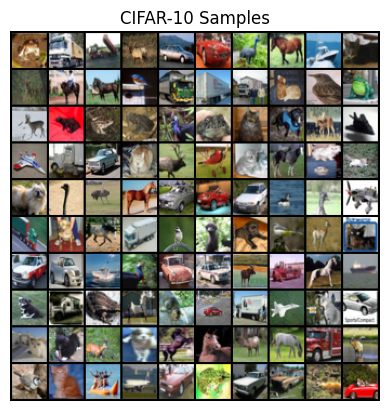

In [7]:
visualize_q2_data()

We'll use a UNet architecture similar to the original [DDPM](https://arxiv.org/abs/2006.11239) paper. We provide the following pseudocode for each part of the model:
```
def timestep_embedding(timesteps, dim, max_period=10000):
    half = dim // 2
    freqs = np.exp(-np.log(max_period) * np.arange(0, half, dtype=float32) / half)
    args = timesteps[:, None].astype(float32) * freqs[None]
    embedding = cat([np.cos(args), np.sin(args)], axis=-1)
    if dim % 2:
        embedding = cat([embedding, np.zeros_like(embedding[:, :1])], axis=-1)
    return embedding

ResidualBlock(in_channels, out_channels, temb_channels)
    Given x, temb
    h = Conv2d(in_channels, out_channels, 3, padding=1)(x)
    h = GroupNorm(num_groups=8, num_channels=out_channels)(h)
    h = SiLU()(h)
    
    temb = Linear(temb_channels, out_channels)(temb)
    h += temb[:, :, None, None] # h is BxDxHxW, temb is BxDx1x1
    
    h = Conv2d(out_channels, out_channels, 3, padding=1)(h)
    h = GroupNorm(num_groups=8, num_channels=out_channels)(h)
    h = SiLU()(h)
    
    if in_channels != out_channels:
        x = Conv2d(in_channels, out_channels, 1)(x)
    return x + h
    
Downsample(in_channels)
    Given x
    return Conv2d(in_channels, in_channels, 3, stride=2, padding=1)(x)

Upsample(in_channels)
    Given x
    x = interpolate(x, scale_factor=2)
    x = Conv2d(in_channels, in_channels, 3, padding=1)(x)
    return x
    
UNet(in_channels, hidden_dims, blocks_per_dim)
    Given x, t
    temb_channels = hidden_dims[0] * 4
    emb = timestep_embedding(t, hidden_dims[0])
    emb = Sequential(Linear(hidden_dims[0], temb_channels), SiLU(), Linear(temb_channels, temb_channels))(emb)
    
    h = Conv2d(in_channels, hidden_dims[0], 3, padding=1)(x)
    hs = [h]
    prev_ch = hidden_dims[0]
    down_block_chans = [prev_ch]
    for i, hidden_dim in enumerate(hidden_dims):
        for _ in range(blocks_per_dim):
            h = ResidualBlock(prev_ch, hidden_dim, temb_channels)(h, emb)
            hs.append(h)
            prev_ch = hidden_dim
            down_block_chans.append(prev_ch)
        if i != len(hidden_dims) - 1:
            h = Downsample(prev_ch)(h)
            hs.append(h)
            down_block_chans.append(prev_ch)
    
    h = ResidualBlock(prev_ch, prev_ch, temb_channels)(h, emb)
    h = ResidualBlock(prev_ch, prev_ch, temb_channels)(h, emb)
    
    for i, hidden_dim in list(enumerate(hidden_dims))[::-1]:
        for j in range(blocks_per_dim + 1):
            dch = down_block_chans.pop()
            h = ResidualBlock(prev_ch + dch, hidden_dim, temb_channels)(cat(h, hs.pop()), emb)
            prev_ch = hidden_dim
            if i and j == blocks_per_dim:
                h = Upsample(prev_ch)(h)
    
    h = GroupNorm(num_groups=8, num_channels=prev_ch)(h)
    h = SiLU()(h)
    out = Conv2d(prev_ch, in_channels, 3, padding=1)(h)
    return out
```

**Hyperparameter details**
* Normalize data to [-1, 1]
* UNET with hidden_dims as [64, 128, 256, 512] and 2 blocks_per_dim
* Train 60 epochs, batch size 256, Adam with LR 1e-3 (100 warmup steps, cosine decay to 0)
* For diffusion schedule, sampling and loss, use the same setup as Q1

You may also find it helpful to clip $\hat{x} = \frac{x_t - \sigma_t \hat{\epsilon}}{\alpha_t}$ to [-1, 1] during each sampling step.

In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from torch.utils.data import DataLoader
from transformers import get_cosine_schedule_with_warmup
import math

def timestep_embedding(timesteps, dim, max_period=10000):
    """
    Create sinusoidal timestep embeddings.
    """
    half = dim // 2
    freqs = torch.exp(
        -math.log(max_period) * torch.arange(start=0, end=half, dtype=torch.float32, device=timesteps.device) / half
    )
    args = timesteps[:, None].float() * freqs[None]
    embedding = torch.cat([torch.cos(args), torch.sin(args)], dim=-1)
    if dim % 2:
        embedding = torch.cat([embedding, torch.zeros_like(embedding[:, :1])], dim=-1)
    return embedding

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, temb_channels):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, padding=1)
        self.norm1 = nn.GroupNorm(num_groups=8, num_channels=out_channels)
        
        self.temb_proj = nn.Linear(temb_channels, out_channels)
        
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, padding=1)
        self.norm2 = nn.GroupNorm(num_groups=8, num_channels=out_channels)
        
        self.in_channels = in_channels
        self.out_channels = out_channels
        
        # Shortcut connection for dimension matching
        if self.in_channels != self.out_channels:
            self.shortcut = nn.Conv2d(self.in_channels, self.out_channels, 1)
        else:
            self.shortcut = nn.Identity()
        
    def forward(self, x, temb):
        # First conv + norm + activation
        h = self.conv1(x)
        h = self.norm1(h)
        h = F.silu(h)
        
        # Add time embedding
        temb_proj = self.temb_proj(temb)
        h += temb_proj[:, :, None, None]  # h is BxDxHxW, temb is BxDx1x1
        
        # Second conv + norm + activation
        h = self.conv2(h)
        h = self.norm2(h)
        h = F.silu(h)
        
        # Skip connection
        return self.shortcut(x) + h

class Downsample(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, in_channels, 3, stride=2, padding=1)
    
    def forward(self, x):
        return self.conv(x)
    
class Upsample(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, in_channels, 3, padding=1)
    
    def forward(self, x):
        x = F.interpolate(x, scale_factor=2)
        x = self.conv(x)
        return x
    
class Unet(nn.Module):
    def __init__(self, in_channels, hidden_dims, blocks_per_dim):
        super().__init__()
        self.in_channels = in_channels
        self.hidden_dims = hidden_dims
        self.blocks_per_dim = blocks_per_dim
        temb_channels = hidden_dims[0] * 4
        
        # Time embedding layers
        self.time_mlp = nn.Sequential(
            nn.Linear(hidden_dims[0], temb_channels),
            nn.SiLU(),
            nn.Linear(temb_channels, temb_channels)
        )
        
        # Initial convolution
        self.init_conv = nn.Conv2d(in_channels, hidden_dims[0], 3, padding=1)
        
        # Build the architecture following the pseudocode exactly
        self.down_blocks = nn.ModuleList()
        self.down_samples = nn.ModuleList()
        self.up_blocks = nn.ModuleList()
        self.up_samples = nn.ModuleList()
        
        # Track channel progression for upsampling path
        self.down_block_channels = []
        
        # Build downsampling path
        prev_ch = hidden_dims[0]
        self.down_block_channels.append(prev_ch)  # for initial conv
        
        for i, hidden_dim in enumerate(hidden_dims):
            level_blocks = nn.ModuleList()
            for _ in range(blocks_per_dim):
                level_blocks.append(ResidualBlock(prev_ch, hidden_dim, temb_channels))
                prev_ch = hidden_dim
                self.down_block_channels.append(prev_ch)
            self.down_blocks.append(level_blocks)
            
            if i != len(hidden_dims) - 1:
                self.down_samples.append(Downsample(prev_ch))
                self.down_block_channels.append(prev_ch)  # for downsample
        
        # Middle blocks
        self.mid_block1 = ResidualBlock(prev_ch, prev_ch, temb_channels)
        self.mid_block2 = ResidualBlock(prev_ch, prev_ch, temb_channels)
        
        # Build upsampling path - reverse order of hidden_dims
        up_dims = list(reversed(hidden_dims))
        for i, hidden_dim in enumerate(up_dims):
            level_blocks = nn.ModuleList()
            for j in range(blocks_per_dim + 1):
                # Calculate input channels: current + skip connection
                if j == 0:
                    # First block of each level gets concatenated with skip
                    skip_ch = self.down_block_channels[-(1 + j + i * (blocks_per_dim + 1))]
                    input_ch = prev_ch + skip_ch
                else:
                    # Subsequent blocks also get skip connections according to pseudocode
                    skip_ch = self.down_block_channels[-(1 + j + i * (blocks_per_dim + 1))]
                    input_ch = prev_ch + skip_ch
                
                level_blocks.append(ResidualBlock(input_ch, hidden_dim, temb_channels))
                prev_ch = hidden_dim
            
            self.up_blocks.append(level_blocks)
            
            # Add upsampling layer for all but the last level (i=0 corresponds to the first level in original order)
            if i < len(up_dims) - 1:
                self.up_samples.append(Upsample(prev_ch))
        
        # Final layers
        self.final_norm = nn.GroupNorm(num_groups=8, num_channels=prev_ch)
        self.final_conv = nn.Conv2d(prev_ch, in_channels, 3, padding=1)
        
    def forward(self, x, t):
        # Time embedding
        emb = timestep_embedding(t, self.hidden_dims[0])
        emb = self.time_mlp(emb) # [B,256]
        
        # Initial convolution
        h = self.init_conv(x) # [B,64,32,32]
        hs = [h] 
        down_block_chans = [self.hidden_dims[0]]  # Start with initial conv channels
        
        # Downsampling path - exactly following pseudocode
        prev_ch = self.hidden_dims[0]
        for i, hidden_dim in enumerate(self.hidden_dims):
            for block in self.down_blocks[i]:
                h = block(h, emb)
                hs.append(h)
                prev_ch = hidden_dim
                down_block_chans.append(prev_ch)
            
            if i != len(self.hidden_dims) - 1:
                h = self.down_samples[i](h)
                hs.append(h)
                down_block_chans.append(prev_ch)
        
        # Middle blocks
        h = self.mid_block1(h, emb)
        h = self.mid_block2(h, emb)
        up_dims = list(reversed(self.hidden_dims))
        for i, hidden_dim in enumerate(up_dims):
            for j in range(self.blocks_per_dim + 1):
                dch = down_block_chans.pop()
                skip_h = hs.pop()
                h = torch.cat([h, skip_h], dim=1)
                h = self.up_blocks[i][j](h, emb)
                prev_ch = hidden_dim
                if j == self.blocks_per_dim and i < len(up_dims) - 1:
                    h = self.up_samples[i](h)
        
        h = self.final_norm(h)
        h = F.silu(h)
        out = self.final_conv(h)
        
        return out

def broadcast(values, broadcast_to):
    """Ensure values tensor is on the same device and properly broadcasted"""
    values = values.flatten()
    while len(values.shape) < len(broadcast_to.shape):
        values = values.unsqueeze(-1)
    return values.to(broadcast_to.device)

def forward_diffusion(images, timesteps) -> tuple[torch.Tensor, torch.Tensor]:
    """
    https://arxiv.org/pdf/2006.11239.pdf, equation (14), the term inside epsilon_theta
    """
    device = images.device
    gaussian_noise = torch.randn(images.shape, device=device)
    betas = torch.linspace(1e-4, 1e-2, 1000, device=device)
    alphas = 1 - betas
    alphas_hat = torch.cumprod(alphas, dim=0)
    alpha_hat = alphas_hat[timesteps]
    alpha_hat = broadcast(alpha_hat, images)
    
    return torch.sqrt(alpha_hat) * images + torch.sqrt(1 - alpha_hat) * gaussian_noise, gaussian_noise

def make_subsequence(num_steps: int, total_steps: int = 1000):
    # e.g., t = [999, ..., 0] sampled in num_steps evenly-spaced points
    # flip so we go from 999 -> 0
    idx = torch.linspace(total_steps - 1, 0, num_steps).round().long()
    return idx

def reverse_diffusion(model, device, num_steps=1000, shape=(10,3,32,32)):
    model.eval()
    with torch.no_grad():
        T = 1000
        x = torch.randn(shape, device=device)

        # Use the SAME betas as training (best: load from checkpoint)
        betas  = torch.linspace(1e-4, 1e-2, T, device=device)
        alphas = 1 - betas
        abar   = torch.cumprod(alphas, dim=0)  # alpha_bar

        ts = make_subsequence(num_steps, total_steps=T).to(device)  # e.g., [999,...,0]
        for i in range(len(ts)-1):
            t      = ts[i].item()
            t_next = ts[i+1].item()              # the actual target step
            t_vec  = torch.full((x.size(0),), t,  device=device, dtype=torch.long)

            eps     = model(x, t_vec)            # ε-prediction
            abar_t  = abar[t]
            x0_pred = (x - torch.sqrt(1-abar_t) * eps) / torch.sqrt(abar_t)

            # DDIM update (eta=0)
            abar_s  = abar[t_next]
            x = torch.sqrt(abar_s) * x0_pred + torch.sqrt(1-abar_s) * eps

        # final step to t=0 if needed
        return x.clamp(-1, 1)
    
def q2(train_data, test_data):
    """
    train_data: A (50000, 32, 32, 3) numpy array of images in [0, 1]
    test_data: A (10000, 32, 32, 3) numpy array of images in [0, 1]

    Returns
    - a (# of training iterations,) numpy array of train losses evaluated every minibatch
    - a (# of num_epochs + 1,) numpy array of test losses evaluated at the start of training and the end of every epoch
    - a numpy array of size (10, 10, 32, 32, 3) of samples in [0, 1] drawn from your model.
      The array represents a 10 x 10 grid of generated samples. Each row represents 10 samples generated
      for a specific number of diffusion timesteps. Do this for 10 evenly logarithmically spaced integers
      1 to 512, i.e. np.power(2, np.linspace(0, 9, 10)).astype(int)
    """
    
    train_losses = []
    test_losses = []
    
    # Normalize data to [-1, 1]
    train_data = train_data * 2 - 1
    test_data = test_data * 2 - 1
    
    # Convert to PyTorch tensors and change to channel first
    train_data = torch.tensor(train_data, dtype=torch.float32)
    test_data = torch.tensor(test_data, dtype=torch.float32)
    train_data = torch.permute(train_data, (0, 3, 1, 2)).contiguous()
    test_data = torch.permute(test_data, (0, 3, 1, 2)).contiguous()
    
    batch_size = 256
    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)
    
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    hidden_dims = [64, 128, 256, 512]
    model = Unet(in_channels=3, hidden_dims=hidden_dims, blocks_per_dim=2)
    
    model = model.to(device)
    
    model = torch.compile(model)
    
    epochs = 60
    learning_rate = 1e-3
    warmup_steps = 100
    num_timesteps = 1000
    optimizer = torch.optim.Adam(params=model.parameters(), lr=learning_rate)
    scheduler = get_cosine_schedule_with_warmup(
        optimizer, 
        num_warmup_steps=warmup_steps, 
        num_training_steps=epochs * len(train_loader)
    )
    
    # Training configuration for saving/loading
    checkpoint_path = 'diffusion_model_checkpoint.pth'
    config = {
        'hidden_dims': hidden_dims,
        'blocks_per_dim': 2,
        'in_channels': 3,
        'epochs': epochs,
        'learning_rate': learning_rate,
        'batch_size': batch_size,
        'num_timesteps': num_timesteps,
        'warmup_steps': warmup_steps
    }
    
    # Try to load existing checkpoint
    start_epoch = 0
    if os.path.exists(checkpoint_path):
        print(f"Loading checkpoint from {checkpoint_path}")

        checkpoint = torch.load(checkpoint_path, weights_only=False, map_location=device)
        
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
        start_epoch = checkpoint['epoch'] + 1
        train_losses = checkpoint['train_losses']
        test_losses = checkpoint['test_losses']
        print(f"Resuming training from epoch {start_epoch}")
    
    # Initialize best model tracking
    best_test_loss = float('inf')
    best_model_state = None
    
    # Evaluate initial test loss if starting from scratch
    if start_epoch == 0:
        model.eval()
        with torch.no_grad():
            total_test_loss = []
            for batch in test_loader:
                x = batch.to(device)
                timesteps = torch.randint(0, num_timesteps, (x.size(0),), device=device).long()
                noisy_images, noise = forward_diffusion(x, timesteps)
                pred_noise = model(noisy_images, timesteps)
                loss = F.mse_loss(pred_noise, noise)
                total_test_loss.append(loss.item())
            initial_test_loss = np.mean(total_test_loss)
            test_losses.append(initial_test_loss)
            
            # Save initial model as best if it's the first
            best_test_loss = initial_test_loss
            best_model_state = model.state_dict().copy()
    else:
        # If resuming, find the best test loss so far
        if test_losses:
            best_test_loss = min(test_losses)
            best_model_state = model.state_dict().copy()
    
    for epoch in range(start_epoch, epochs):
        model.train()
        total_loss = []
        
        for batch in train_loader:
            x = batch.to(device)
            optimizer.zero_grad()
            timesteps = torch.randint(0, num_timesteps, (x.size(0),), device=device).long()
            
            noisy_images, noise = forward_diffusion(x, timesteps)
            pred_noise = model(noisy_images, timesteps)
            
            loss = F.mse_loss(pred_noise, noise)
            loss.backward()
            
            optimizer.step()
            scheduler.step()
            train_losses.append(loss.item())
            total_loss.append(loss.item())
        
        # Evaluate test loss at end of epoch
        model.eval()
        with torch.no_grad():
            total_test_loss = []
            for batch in test_loader:
                x = batch.to(device)
                timesteps = torch.randint(0, num_timesteps, (x.size(0),), device=device).long()
                noisy_images, noise = forward_diffusion(x, timesteps)
                pred_noise = model(noisy_images, timesteps)
                loss = F.mse_loss(pred_noise, noise)
                total_test_loss.append(loss.item())
            current_test_loss = np.mean(total_test_loss)
            test_losses.append(current_test_loss)
            
            # Save best model
            if current_test_loss < best_test_loss:
                best_test_loss = current_test_loss
                best_model_state = model.state_dict().copy()
        
        if epoch % 1 == 0:
            print(f"Epoch {epoch}; train loss: {np.mean(total_loss):.4f}; test loss: {test_losses[-1]:.4f}")
        
        # Save checkpoint every 5 epochs
        if (epoch + 1) % 5 == 0:
            checkpoint = {
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'train_losses': train_losses,
                'test_losses': test_losses,
                'config': config,
                'best_test_loss': best_test_loss,
                'best_model_state_dict': best_model_state
            }
            torch.save(checkpoint, checkpoint_path)
            print(f"Checkpoint saved at epoch {epoch}")
    
    # Save final checkpoint and best model
    final_checkpoint = {
        'epoch': epochs - 1,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'train_losses': train_losses,
        'test_losses': test_losses,
        'config': config,
        'best_test_loss': best_test_loss,
        'best_model_state_dict': best_model_state
    }
    torch.save(final_checkpoint, checkpoint_path)
    
    # Save best model separately
    if best_model_state is not None:
        torch.save(best_model_state, 'best_diffusion_model_bs_256.pth')
        model.load_state_dict(best_model_state)
        print(f"Best model saved with test loss: {best_test_loss:.4f}")
    
    # Generate samples
    timestep_values = np.power(2, np.linspace(0, 9, 10)).astype(int)
    samples = np.zeros((10, 10, 32, 32, 3))
    
    for i, num_steps in enumerate(timestep_values):
        # Generate 10 samples with num_steps diffusion steps
        generated = reverse_diffusion(model, device, num_steps=min(num_steps, 1000), shape=(10, 3, 32, 32))
        
        # Convert back to [0, 1] and change to channel last
        generated = torch.clamp((generated + 1) / 2, 0, 1)
        generated = generated.permute(0, 2, 3, 1).cpu().numpy()
        samples[i] = generated
    
    return np.array(train_losses), np.array(test_losses), samples

In [9]:
# q2_save_results(q2)

# Question 3: Class-Conditional Latent-Space Diffusion on CIFAR-10 with DiT [60pt]

In this question, we will train latent-space [Diffusion Transformer (DiT)](https://arxiv.org/abs/2212.09748) model on CIFAR-10 **with class conditioning.**

Execute the cell below to visualize our datasets.

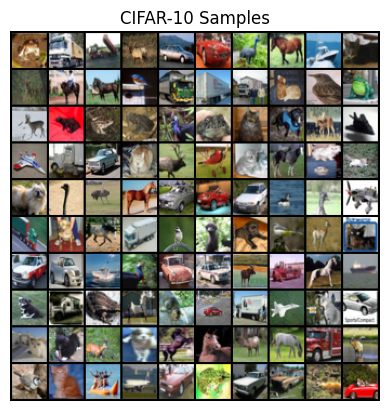

Labels: [6, 9, 9, 4, 1, 1, 2, 7, 8, 3, 4, 7, 7, 2, 9, 9, 9, 3, 2, 6, 4, 3, 6, 6, 2, 6, 3, 5, 4, 0, 0, 9, 1, 3, 4, 0, 3, 7, 3, 3, 5, 2, 2, 7, 1, 1, 1, 2, 2, 0, 9, 5, 7, 9, 2, 2, 5, 2, 4, 3, 1, 1, 8, 2, 1, 1, 4, 9, 7, 8, 5, 9, 6, 7, 3, 1, 9, 0, 3, 1, 3, 5, 4, 5, 7, 7, 4, 7, 9, 4, 2, 3, 8, 0, 1, 6, 1, 1, 4, 1]


In [10]:
visualize_q3_data()

## Part 3(a) VAE reconstructions and Scale Factor [10pt]

Similar to how we learned a AR model in VQGAN latent space for homework 1, in this question, you will train a diffusion model in the latent space of a VAE. Note that since diffusion models can model continuous distributions, we do not need a discretization bottleneck in the VAE, and the latent space itself is continuous.

Below, we specify each of the relevant properties or functions that you may need.

In [11]:
# @property
# def latent_shape(self) -> Tuple[int, int, int]:
#     """Size of the encoded representation"""
#
# def encode(self, x: np.ndarray) -> np.ndarray:
#     """Encode an image x. Note: Channel dim is in dim 1
#
#     Args:
#         x (np.ndarray, dtype=float32): Image to encode. shape=(batch_size, 3, 32, 32). Values in [-1, 1]
#
#     Returns:
#         np.ndarray: Encoded image. shape=(batch_size, 4, 8, 8). Unbounded values
#     """
#
# def decode(self, z: np.ndarray) -> np.ndarray:
#     """Decode an encoded image.
#
#     Args:
#         z (np.ndarray, dtype=float32): Encoded image. shape=(batch_size, 4, 8, 8). Unbounded values.
#
#     Returns:
#         np.ndarray: Decoded image. shape=(batch_size, 3, 32, 32). Values in [-1, 1]
#     """
#

In this part, feed the given images through the VAE to compute and visualize reconstructions. In addition, you will compute a scale factor that will be needed during diffusion training to help normalize the data.

To estimate the scale factor, encode 1000 images into the VAE latent space, flatten the entire tensor along all dimensions, and compute the standard deviation.

In [12]:
def q3_a(images, vae):
    """
    images: (1000, 32, 32, 3) numpy array in [0, 1], the images to pass through the encoder and decoder of the vae
    vae: a vae model, trained on the relevant dataset

    Returns
    - a numpy array of size (50, 2, 32, 32, 3) of the decoded image in [0, 1] consisting of pairs
      of real and reconstructed images
    - a float that is the scale factor
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    vae.to(device)
    
    # Convert images to tensor and scale to [-1, 1]
    original_images = images.copy()
    images_tensor = torch.tensor(images, dtype=torch.float32).permute(0, 3, 1, 2).to(device)
    images_tensor = (images_tensor - 0.5) * 2
    
    # Encode and decode images
    vae.eval()
    with torch.inference_mode():
        encoded_images = vae.encode(images_tensor)
        decoded_images = vae.decode(encoded_images)
    
    # Convert back to numpy and scale to [0, 1]
    decoded_images = decoded_images.permute(0, 2, 3, 1).cpu().numpy()
    decoded_images = (decoded_images + 1) / 2
    
    # Create pairs of original and reconstructed images
    image_pairs = np.stack((original_images[:50], decoded_images[:50]), axis=1)
    
    # Compute scale factor
    scale_factor = torch.std(encoded_images.flatten()).item()
    
    return image_pairs, scale_factor

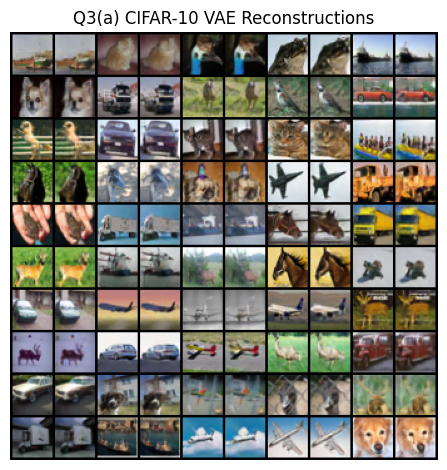

Scale factor: 1.2693


In [13]:
q3a_save_results(q3_a)

## Part 3(b) Diffusion Transformer [30pt]
In this part, you will train a Diffusion Transformer (Dit) on the latent space of the above pretrained VAE. You can use your Transformer implementation from HW1 as the core part of the DiT implementation.

Below, we outline the key modifications needed on top of the standard Transformer for DiT.
```
def get_2d_sincos_pos_embed_from_grid(embed_dim, grid):
    assert embed_dim % 2 == 0

    # use half of dimensions to encode grid_h
    emb_h = get_1d_sincos_pos_embed_from_grid(embed_dim // 2, grid[0])  # (H*W, D/2)
    emb_w = get_1d_sincos_pos_embed_from_grid(embed_dim // 2, grid[1])  # (H*W, D/2)

    emb = np.concatenate([emb_h, emb_w], axis=1) # (H*W, D)
    return emb


def get_1d_sincos_pos_embed_from_grid(embed_dim, pos):
    assert embed_dim % 2 == 0
    omega = np.arange(embed_dim // 2, dtype=np.float64)
    omega /= embed_dim / 2.
    omega = 1. / 10000**omega  # (D/2,)

    pos = pos.reshape(-1)  # (M,)
    out = np.einsum('m,d->md', pos, omega)  # (M, D/2), outer product

    emb_sin = np.sin(out) # (M, D/2)
    emb_cos = np.cos(out) # (M, D/2)

    emb = np.concatenate([emb_sin, emb_cos], axis=1)  # (M, D)
    return emb

def get_2d_sincos_pos_embed(embed_dim, grid_size):
    grid_h = np.arange(grid_size, dtype=np.float32)
    grid_w = np.arange(grid_size, dtype=np.float32)
    grid = np.meshgrid(grid_w, grid_h)  # here w goes first
    grid = np.stack(grid, axis=0)

    grid = grid.reshape([2, 1, grid_size, grid_size])
    pos_embed = get_2d_sincos_pos_embed_from_grid(embed_dim, grid)
    return pos_embed

def modulate(x, shift, scale):
    return x * (1 + scale.unsqueeze(1)) + shift.unsqueeze(1)

DiTBlock(hidden_size, num_heads)
    Given x (B x L x D), c (B x D)
    c = SiLU()(c)
    c = Linear(hidden_size, 6 * hidden_size)(c)
    shift_msa, scale_msa, gate_msa, shift_mlp, scale_mlp, gate_mlp = c.chunk(6, dim=1)
    
    h = LayerNorm(hidden_size, elementwise_affine=False)(x)
    h = modulate(h, shift_msa, scale_msa)
    x = x + gate_msa.unsqueeze(1) * Attention(hidden_size, num_heads)(h)
    
    h = LayerNorm(hidden_size, elementwise_affine=False)(x)
    h = modulate(h, shift_mlp, scale_mlp)
    x = x + gate_mlp.unsqueeze(1) * MLP(hidden_size)(h)
    
    return x
    
FinalLayer(hidden_size, patch_size, out_channels)
    Given x (B x L x D), c (B x D)
    c = SiLU()(c)
    c = Linear(hidden_size, 2 * hidden_size)(c)
    shift, scale = c.chunk(2, dim=1)
    x = LayerNorm(hidden_size, elementwise_affine=False)(x)
    x = modulate(x, shift, scale)
    x = Linear(hidden_size, patch_size * patch_size * out_channels)(x)
    return x
    
DiT(input_shape, patch_size, hidden_size, num_heads, num_layers, num_classes, cfg_dropout_prob)
    Given x (B x C x H x W) - image, y (B) - class label, t (B) - diffusion timestep
    x = patchify_flatten(x) # B x C x H x W -> B x (H // P * W // P) x D, P is patch_size
    x += pos_embed # see get_2d_sincos_pos_embed
    
    t = compute_timestep_embedding(t) # Same as in UNet
    if training:
        y = dropout_classes(y, cfg_dropout_prob) # Randomly dropout to train unconditional image generation
    y = Embedding(num_classes + 1, hidden_size)(y)
    c = t + y
    
    for _ in range(num_layers):
        x = DiTBlock(hidden_size, num_heads)(x, c)
    
    x = FinalLayer(hidden_size, patch_size, out_channels)(x)
    x = unpatchify(x) # B x (H // P * W // P) x (P * P * C) -> B x C x H x W
    return x
```

**Hyperparameter details**
* Normalize image to [-1, 1], (2) Encode using the VAE, (3) divide latents by the scale_factor compute in part (a)
* Transformer with patch_size 2, hidden_size 512, num_heads 8, num_layers 12
* Train 60 epochs, batch size 256, Adam with LR 1e-3 (100 warmup steps, cosine decay to 0)
* When sampling, remember to multiple the final generated latents by the scale_factor before feeding it through the decoder
* For diffusion schedule, sampling and loss, use the same setup as Q1

For class conditioning, learn an embedding for each class, and an extra embedding to represent the null class. To condition, add the class embedding to the timestep embedding before feeding it into the transformer blocks (see pseudocode). **Train your class conditional diffusion models while dropping out the class (replace with null class) 10% of the time. This will be necessary for part (c).**

**Remember to save your model parameters after training, as you will need them for part (c)**

In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import numpy as np
from typing import Optional, Tuple
from dataclasses import dataclass

@dataclass
class DiTConfig:
    """Configuration for Diffusion Transformer"""
    patch_size: int = 2
    in_channels: int = 3
    hidden_size: int = 384
    depth: int = 12
    num_heads: int = 6
    mlp_ratio: float = 4.0
    class_dropout_prob: float = 0.1
    num_classes: int = 1000
    learn_sigma: bool = True

class PatchEmbed(nn.Module):
    """Image to Patch Embedding"""
    def __init__(self, img_size=32, patch_size=2, in_chans=3, embed_dim=768):
        super().__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2
        
        self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        B, C, H, W = x.shape
        x = self.proj(x).flatten(2).transpose(1, 2)
        return x

class TimestepEmbedder(nn.Module):
    """Embeds scalar timesteps into vector representations"""
    def __init__(self, hidden_size, frequency_embedding_size=256):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(frequency_embedding_size, hidden_size, bias=True),
            nn.SiLU(),
            nn.Linear(hidden_size, hidden_size, bias=True),
        )
        self.frequency_embedding_size = frequency_embedding_size

    @staticmethod
    def timestep_embedding(t, dim, max_period=10000):
        """Create sinusoidal timestep embeddings"""
        half = dim // 2
        freqs = torch.exp(
            -math.log(max_period) * torch.arange(start=0, end=half, dtype=torch.float32) / half
        ).to(device=t.device)
        args = t[:, None].float() * freqs[None]
        embedding = torch.cat([torch.cos(args), torch.sin(args)], dim=-1)
        if dim % 2:
            embedding = torch.cat([embedding, torch.zeros_like(embedding[:, :1])], dim=-1)
        return embedding

    def forward(self, t):
        t_freq = self.timestep_embedding(t, self.frequency_embedding_size)
        t_emb = self.mlp(t_freq)
        return t_emb

class LabelEmbedder(nn.Module):
    """Embeds class labels into vector representations"""
    def __init__(self, num_classes, hidden_size, dropout_prob):
        super().__init__()
        use_cfg_embedding = dropout_prob > 0
        self.embedding_table = nn.Embedding(num_classes + use_cfg_embedding, hidden_size)
        self.num_classes = num_classes
        self.dropout_prob = dropout_prob

    def token_drop(self, labels, force_drop_ids=None):
        """Drop labels to enable classifier-free guidance"""
        if force_drop_ids is None:
            drop_ids = torch.rand(labels.shape[0], device=labels.device) < self.dropout_prob
        else:
            drop_ids = force_drop_ids == 1
        labels = torch.where(drop_ids, self.num_classes, labels)
        return labels

    def forward(self, labels, train, force_drop_ids=None):
        use_dropout = self.dropout_prob > 0
        if (train and use_dropout) or (force_drop_ids is not None):
            labels = self.token_drop(labels, force_drop_ids)
        embeddings = self.embedding_table(labels)
        return embeddings

class Attention(nn.Module):
    """Multi-head self attention"""
    def __init__(self, dim, num_heads=8, qkv_bias=False, attn_drop=0., proj_drop=0.):
        super().__init__()
        assert dim % num_heads == 0, "dim must be divisible by num_heads"
        self.num_heads = num_heads
        head_dim = dim // num_heads
        self.scale = head_dim ** -0.5

        self.qkv = nn.Linear(dim, dim * 3, bias=qkv_bias)
        self.attn_drop = nn.Dropout(attn_drop)
        self.proj = nn.Linear(dim, dim)
        self.proj_drop = nn.Dropout(proj_drop)

    def forward(self, x):
        B, N, C = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, C // self.num_heads).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]

        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        attn = self.attn_drop(attn)

        x = (attn @ v).transpose(1, 2).reshape(B, N, C)
        x = self.proj(x)
        x = self.proj_drop(x)
        return x

class Mlp(nn.Module):
    """MLP block"""
    def __init__(self, in_features, hidden_features=None, out_features=None, act_layer=nn.GELU, drop=0.):
        super().__init__()
        out_features = out_features or in_features
        hidden_features = hidden_features or in_features
        self.fc1 = nn.Linear(in_features, hidden_features)
        self.act = act_layer()
        self.fc2 = nn.Linear(hidden_features, out_features)
        self.drop = nn.Dropout(drop)

    def forward(self, x):
        x = self.fc1(x)
        x = self.act(x)
        x = self.drop(x)
        x = self.fc2(x)
        x = self.drop(x)
        return x

def modulate(x, shift, scale):
    """Modulation function for AdaLN"""
    return x * (1 + scale.unsqueeze(1)) + shift.unsqueeze(1)

class DiTBlock(nn.Module):
    """DiT block with adaptive layer norm conditioning"""
    def __init__(self, hidden_size, num_heads, mlp_ratio=4.0, **block_kwargs):
        super().__init__()
        self.norm1 = nn.LayerNorm(hidden_size, elementwise_affine=False, eps=1e-6)
        self.attn = Attention(hidden_size, num_heads=num_heads, qkv_bias=True, **block_kwargs)
        self.norm2 = nn.LayerNorm(hidden_size, elementwise_affine=False, eps=1e-6)
        mlp_hidden_dim = int(hidden_size * mlp_ratio)
        approx_gelu = lambda: nn.GELU(approximate="tanh")
        self.mlp = Mlp(in_features=hidden_size, hidden_features=mlp_hidden_dim, act_layer=approx_gelu, drop=0)
        self.adaLN_modulation = nn.Sequential(
            nn.SiLU(),
            nn.Linear(hidden_size, 6 * hidden_size, bias=True)
        )

    def forward(self, x, c):
        shift_msa, scale_msa, gate_msa, shift_mlp, scale_mlp, gate_mlp = self.adaLN_modulation(c).chunk(6, dim=1)
        x = x + gate_msa.unsqueeze(1) * self.attn(modulate(self.norm1(x), shift_msa, scale_msa))
        x = x + gate_mlp.unsqueeze(1) * self.mlp(modulate(self.norm2(x), shift_mlp, scale_mlp))
        return x

class FinalLayer(nn.Module):
    """Final layer of DiT"""
    def __init__(self, hidden_size, patch_size, out_channels):
        super().__init__()
        self.norm_final = nn.LayerNorm(hidden_size, elementwise_affine=False, eps=1e-6)
        self.linear = nn.Linear(hidden_size, patch_size * patch_size * out_channels, bias=True)
        self.adaLN_modulation = nn.Sequential(
            nn.SiLU(),
            nn.Linear(hidden_size, 2 * hidden_size, bias=True)
        )

    def forward(self, x, c):
        shift, scale = self.adaLN_modulation(c).chunk(2, dim=1)
        x = modulate(self.norm_final(x), shift, scale)
        x = self.linear(x)
        return x

class DiT(nn.Module):
    """Diffusion Transformer model"""
    def __init__(self, config: DiTConfig, img_size=32):
        super().__init__()
        self.config = config
        self.img_size = img_size
        self.out_channels = config.in_channels * 2 if config.learn_sigma else config.in_channels
        self.num_patches = (img_size // config.patch_size) ** 2

        self.x_embedder = PatchEmbed(img_size, config.patch_size, config.in_channels, config.hidden_size)
        self.t_embedder = TimestepEmbedder(config.hidden_size)
        self.y_embedder = LabelEmbedder(config.num_classes, config.hidden_size, config.class_dropout_prob)
        num_patches = self.x_embedder.num_patches
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches, config.hidden_size), requires_grad=False)

        self.blocks = nn.ModuleList([
            DiTBlock(config.hidden_size, config.num_heads, mlp_ratio=config.mlp_ratio) for _ in range(config.depth)
        ])
        self.final_layer = FinalLayer(config.hidden_size, config.patch_size, self.out_channels)
        self.initialize_weights()

    def initialize_weights(self):
        """Initialize weights"""
        # Initialize transformer layers
        def _basic_init(module):
            if isinstance(module, nn.Linear):
                torch.nn.init.xavier_uniform_(module.weight)
                if module.bias is not None:
                    nn.init.constant_(module.bias, 0)
        self.apply(_basic_init)

        # Initialize positional embedding
        pos_embed = get_2d_sincos_pos_embed(self.pos_embed.shape[-1], int(self.num_patches ** 0.5))
        self.pos_embed.data.copy_(torch.from_numpy(pos_embed).float().unsqueeze(0))

        # Initialize patch embedding
        w = self.x_embedder.proj.weight.data
        nn.init.xavier_uniform_(w.view([w.shape[0], -1]))
        nn.init.constant_(self.x_embedder.proj.bias, 0)

        # Initialize label embedding
        nn.init.normal_(self.y_embedder.embedding_table.weight, std=0.02)

        # Initialize timestep embedding
        nn.init.normal_(self.t_embedder.mlp[0].weight, std=0.02)
        nn.init.normal_(self.t_embedder.mlp[2].weight, std=0.02)

        # Zero-out output layers
        nn.init.constant_(self.final_layer.adaLN_modulation[-1].weight, 0)
        nn.init.constant_(self.final_layer.adaLN_modulation[-1].bias, 0)
        nn.init.constant_(self.final_layer.linear.weight, 0)
        nn.init.constant_(self.final_layer.linear.bias, 0)
        for block in self.blocks:
            nn.init.constant_(block.adaLN_modulation[-1].weight, 0)
            nn.init.constant_(block.adaLN_modulation[-1].bias, 0)

    def unpatchify(self, x):
        """Convert patches back to images"""
        c = self.out_channels
        p = self.config.patch_size
        h = w = int(x.shape[1] ** 0.5)
        assert h * w == x.shape[1]

        x = x.reshape(shape=(x.shape[0], h, w, p, p, c))
        x = torch.einsum('nhwpqc->nchpwq', x)
        imgs = x.reshape(shape=(x.shape[0], c, h * p, h * p))
        return imgs

    def forward(self, x, t, y):
        """Forward pass"""
        x = self.x_embedder(x) + self.pos_embed
        t = self.t_embedder(t)
        y = self.y_embedder(y, self.training)
        c = t + y

        for block in self.blocks:
            x = block(x, c)

        x = self.final_layer(x, c)
        x = self.unpatchify(x)
        return x

def get_2d_sincos_pos_embed(embed_dim, grid_size, cls_token=False, extra_tokens=0):
    """2D sin-cos positional embedding"""
    grid_h = np.arange(grid_size, dtype=np.float32)
    grid_w = np.arange(grid_size, dtype=np.float32)
    grid = np.meshgrid(grid_w, grid_h)
    grid = np.stack(grid, axis=0)
    grid = grid.reshape([2, 1, grid_size, grid_size])
    pos_embed = get_2d_sincos_pos_embed_from_grid(embed_dim, grid)
    if cls_token and extra_tokens > 0:
        pos_embed = np.concatenate([np.zeros([extra_tokens, embed_dim]), pos_embed], axis=0)
    return pos_embed

def get_2d_sincos_pos_embed_from_grid(embed_dim, grid):
    """Get 2D sin-cos positional embedding from grid"""
    assert embed_dim % 2 == 0
    emb_h = get_1d_sincos_pos_embed_from_grid(embed_dim // 2, grid[0])
    emb_w = get_1d_sincos_pos_embed_from_grid(embed_dim // 2, grid[1])
    emb = np.concatenate([emb_h, emb_w], axis=1)
    return emb

def get_1d_sincos_pos_embed_from_grid(embed_dim, pos):
    """Get 1D sin-cos positional embedding from grid"""
    assert embed_dim % 2 == 0
    omega = np.arange(embed_dim // 2, dtype=np.float64)
    omega /= embed_dim / 2.
    omega = 1. / 10000**omega
    pos = pos.reshape(-1)
    out = np.einsum('m,d->md', pos, omega)
    emb_sin = np.sin(out)
    emb_cos = np.cos(out)
    emb = np.concatenate([emb_sin, emb_cos], axis=1)
    return emb

class DiffusionScheduler:
    """DDPM noise scheduler"""
    def __init__(self, num_timesteps=1000, beta_start=0.0001, beta_end=0.02, device=None):
        self.num_timesteps = num_timesteps
        self.device = device
        
        betas = torch.linspace(beta_start, beta_end, num_timesteps)
        alphas = 1.0 - betas
        alphas_cumprod = torch.cumprod(alphas, dim=0)
        alphas_cumprod_prev = F.pad(alphas_cumprod[:-1], (1, 0), value=1.0)
        sqrt_recip_alphas = torch.sqrt(1.0 / alphas)
        sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
        sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - alphas_cumprod)
        posterior_variance = (
            betas * (1.0 - alphas_cumprod_prev) / (1.0 - alphas_cumprod)
        )
        
        # Store on device if specified
        if device is not None:
            self.betas = betas.to(device)
            self.alphas = alphas.to(device)
            self.alphas_cumprod = alphas_cumprod.to(device)
            self.alphas_cumprod_prev = alphas_cumprod_prev.to(device)
            self.sqrt_recip_alphas = sqrt_recip_alphas.to(device)
            self.sqrt_alphas_cumprod = sqrt_alphas_cumprod.to(device)
            self.sqrt_one_minus_alphas_cumprod = sqrt_one_minus_alphas_cumprod.to(device)
            self.posterior_variance = posterior_variance.to(device)
        else:
            self.betas = betas
            self.alphas = alphas
            self.alphas_cumprod = alphas_cumprod
            self.alphas_cumprod_prev = alphas_cumprod_prev
            self.sqrt_recip_alphas = sqrt_recip_alphas
            self.sqrt_alphas_cumprod = sqrt_alphas_cumprod
            self.sqrt_one_minus_alphas_cumprod = sqrt_one_minus_alphas_cumprod
            self.posterior_variance = posterior_variance

    def to(self, device):
        """Move scheduler to device"""
        self.device = device
        self.betas = self.betas.to(device)
        self.alphas = self.alphas.to(device)
        self.alphas_cumprod = self.alphas_cumprod.to(device)
        self.alphas_cumprod_prev = self.alphas_cumprod_prev.to(device)
        self.sqrt_recip_alphas = self.sqrt_recip_alphas.to(device)
        self.sqrt_alphas_cumprod = self.sqrt_alphas_cumprod.to(device)
        self.sqrt_one_minus_alphas_cumprod = self.sqrt_one_minus_alphas_cumprod.to(device)
        self.posterior_variance = self.posterior_variance.to(device)
        return self

    def add_noise(self, x_start, noise, timesteps):
        """Add noise to the original images"""
        sqrt_alphas_cumprod_t = self.sqrt_alphas_cumprod[timesteps]
        sqrt_one_minus_alphas_cumprod_t = self.sqrt_one_minus_alphas_cumprod[timesteps]
        
        # Reshape for broadcasting
        sqrt_alphas_cumprod_t = sqrt_alphas_cumprod_t.reshape(-1, 1, 1, 1)
        sqrt_one_minus_alphas_cumprod_t = sqrt_one_minus_alphas_cumprod_t.reshape(-1, 1, 1, 1)
        
        return sqrt_alphas_cumprod_t * x_start + sqrt_one_minus_alphas_cumprod_t * noise

    def denoise_step(self, model_output, timestep, sample):
        """Single denoising step"""
        t = timestep
        if isinstance(t, int):
            t = torch.tensor([t], device=sample.device)
        
        beta_t = self.betas[t]
        sqrt_one_minus_alphas_cumprod_t = self.sqrt_one_minus_alphas_cumprod[t]
        sqrt_recip_alphas_t = self.sqrt_recip_alphas[t]
        
        # Reshape for broadcasting
        beta_t = beta_t.reshape(-1, 1, 1, 1)
        sqrt_one_minus_alphas_cumprod_t = sqrt_one_minus_alphas_cumprod_t.reshape(-1, 1, 1, 1)
        sqrt_recip_alphas_t = sqrt_recip_alphas_t.reshape(-1, 1, 1, 1)
        
        # Compute predicted original sample
        pred_original_sample = sqrt_recip_alphas_t * (
            sample - beta_t * model_output / sqrt_one_minus_alphas_cumprod_t
        )
        
        # Add noise for non-final timesteps
        if t[0] > 0:
            posterior_variance_t = self.posterior_variance[t].reshape(-1, 1, 1, 1)
            noise = torch.randn_like(sample)
            pred_original_sample = pred_original_sample + torch.sqrt(posterior_variance_t) * noise
            
        return pred_original_sample

def q3_b(train_data, train_labels, test_data, test_labels, vae):
    """
    train_data: A (50000, 32, 32, 3) numpy array of images in [0, 1]
    train_labels: A (50000,) numpy array of class labels
    test_data: A (10000, 32, 32, 3) numpy array of images in [0, 1]
    test_labels: A (10000,) numpy array of class labels
    vae: a pretrained VAE
    Returns
    - a (# of training iterations,) numpy array of train losses evaluated every minibatch
    - a (# of num_epochs + 1,) numpy array of test losses evaluated at the start of training and the end of every epoch
    - a numpy array of size (10, 10, 32, 32, 3) of samples in [0, 1] drawn from your model.
      The array represents a 10 x 10 grid of generated samples. Each row represents 10 samples generated
      for a specific class (i.e. row 0 is class 0, row 1 class 1, ...). Use 512 diffusion timesteps
    """
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    import numpy as np
    from torch.utils.data import DataLoader, TensorDataset
    from torch.optim import Adam
    from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR
    import math
    import os
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    # Checkpoint file path
    checkpoint_path = 'q3b_checkpoint.pth'
    
    # Step 1: Encode data with VAE and compute scale factor
    with torch.no_grad():
        # Normalize to [-1, 1] and convert to tensor
        train_tensor = torch.from_numpy(train_data).float().permute(0, 3, 1, 2) * 2.0 - 1.0
        test_tensor = torch.from_numpy(test_data).float().permute(0, 3, 1, 2) * 2.0 - 1.0
        
        # Encode in batches to avoid memory issues
        batch_size_encode = 100
        train_latents = []
        for i in range(0, len(train_tensor), batch_size_encode):
            batch = train_tensor[i:i+batch_size_encode]
            # Convert to numpy for VAE (VAE expects numpy arrays)
            batch_np = batch.numpy()
            # VAE encode returns numpy array
            latents = vae.encode(batch_np)
            train_latents.append(latents)
        train_latents = torch.cat(train_latents, dim=0)
        
        test_latents = []
        for i in range(0, len(test_tensor), batch_size_encode):
            batch = test_tensor[i:i+batch_size_encode]
            # Convert to numpy for VAE (VAE expects numpy arrays)
            batch_np = batch.numpy()
            # VAE encode returns numpy array
            latents = vae.encode(batch_np)
            # Convert back to tensor
            test_latents.append(latents)
        test_latents = torch.cat(test_latents, dim=0)
        
        # Compute scale factor (std of all latents)
        scale_factor = torch.cat([train_latents, test_latents], dim=0).std().item()
        
        # Divide by scale factor
        train_latents = train_latents / scale_factor
        test_latents = test_latents / scale_factor
    
    # Step 2: Setup model with correct hyperparameters (EXACTLY as specified in instructions)
    latent_channels = train_latents.shape[1]  # Should be 4 for VAE
    latent_size = train_latents.shape[2]      # Should be 8x8 for 32x32 images
    
    # Configure EXACTLY according to the hyperparameter details in the guide:
    # - patch_size 2 
    # - hidden_size 512
    # - num_heads 8
    # - num_layers 12
    # - Train your class conditional diffusion models while dropping out the class (replace with null class) 10% of the time
    config = DiTConfig(
        patch_size=2,                 # As specified: patch_size 2
        in_channels=latent_channels,  # Should be 4 for VAE latents
        hidden_size=512,              # As specified: hidden_size 512
        depth=12,                     # As specified: num_layers 12
        num_heads=8,                  # As specified: num_heads 8
        mlp_ratio=4.0,
        class_dropout_prob=0.1,       # As specified: 10% dropout for class conditioning
        num_classes=10,               # CIFAR-10 has 10 classes
        learn_sigma=False             # Don't predict sigma, just noise
    )
    
    model = DiT(config, img_size=latent_size).to(device)
    scheduler = DiffusionScheduler(num_timesteps=1000, device=device)
    
    # Step 3: Setup training
    train_labels_tensor = torch.from_numpy(train_labels).long()
    test_labels_tensor = torch.from_numpy(test_labels).long()
    
    train_dataset = TensorDataset(train_latents, train_labels_tensor)
    test_dataset = TensorDataset(test_latents, test_labels_tensor)
    
    # As specified: batch size 256
    train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)
    
    # As specified: Adam with LR 1e-3
    optimizer = Adam(model.parameters(), lr=1e-3)
    
    # As specified: 100 warmup steps, cosine decay to 0
    num_epochs = 60  # As specified: Train 60 epochs
    steps_per_epoch = len(train_loader)
    total_steps = num_epochs * steps_per_epoch
    warmup_steps = 100
    
    warmup_scheduler = LinearLR(optimizer, start_factor=0.1, total_iters=warmup_steps)
    cosine_scheduler = CosineAnnealingLR(optimizer, T_max=total_steps-warmup_steps, eta_min=0)
    lr_scheduler = SequentialLR(optimizer, 
                               schedulers=[warmup_scheduler, cosine_scheduler], 
                               milestones=[warmup_steps])
    
    # Initialize training variables
    train_losses = []
    test_losses = []
    start_epoch = 0
    global_step = 0
    
    # Check for existing checkpoint
    if os.path.exists(checkpoint_path):
        print(f"Loading checkpoint from {checkpoint_path}")
        # Use weights_only=False to fix the UnpicklingError
        checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        lr_scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
        start_epoch = checkpoint['epoch']
        global_step = checkpoint.get('global_step', 0)
        train_losses = checkpoint['train_losses']
        test_losses = checkpoint['test_losses']
        print(f"Resuming training from epoch {start_epoch + 1}, global step {global_step}")
    else:
        # Initial test loss only if starting from scratch
        with torch.no_grad():
            model.eval()
            test_loss = 0
            for x_test, y_test in test_loader:
                x_test, y_test = x_test.to(device), y_test.to(device)
                batch_size = x_test.shape[0]
                
                noise = torch.randn_like(x_test)
                timesteps = torch.randint(0, scheduler.num_timesteps, (batch_size,), device=device)
                noisy_images = scheduler.add_noise(x_test, noise, timesteps)
                predicted_noise = model(noisy_images, timesteps, y_test)
                loss = F.mse_loss(predicted_noise, noise)
                test_loss += loss.item()
            
            test_losses.append(test_loss / len(test_loader))
            model.train()
        
        print(f"Initial test loss: {test_losses[0]:.4f}")
    
    # Step 4: Training loop
    model.train()
    
    for epoch in range(start_epoch, num_epochs):
        epoch_train_losses = []
        
        for batch_idx, (x, y) in enumerate(train_loader):
            x, y = x.to(device), y.to(device)
            batch_size = x.shape[0]
            
            # Sample noise and timesteps
            noise = torch.randn_like(x)
            timesteps = torch.randint(0, scheduler.num_timesteps, (batch_size,), device=device)
            
            # Add noise to latents
            noisy_images = scheduler.add_noise(x, noise, timesteps)
            
            # Predict noise with class conditioning and dropout
            predicted_noise = model(noisy_images, timesteps, y)
            
            # Compute loss
            loss = F.mse_loss(predicted_noise, noise)
            
            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            lr_scheduler.step()
            
            train_losses.append(loss.item())
            epoch_train_losses.append(loss.item())
            global_step += 1
        
        # Evaluate test loss at end of epoch
        with torch.no_grad():
            model.eval()
            test_loss = 0
            for x_test, y_test in test_loader:
                x_test, y_test = x_test.to(device), y_test.to(device)
                batch_size = x_test.shape[0]
                
                noise = torch.randn_like(x_test)
                timesteps = torch.randint(0, scheduler.num_timesteps, (batch_size,), device=device)
                noisy_images = scheduler.add_noise(x_test, noise, timesteps)
                predicted_noise = model(noisy_images, timesteps, y_test)
                loss = F.mse_loss(predicted_noise, noise)
                test_loss += loss.item()
            
            test_losses.append(test_loss / len(test_loader))
            model.train()
        
        avg_train_loss = np.mean(epoch_train_losses)
        print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {avg_train_loss:.4f}, Test Loss: {test_losses[-1]:.4f}")
        
        # Save checkpoint every 5 epochs
        if (epoch + 1) % 1 == 0:
            checkpoint = {
                'epoch': epoch + 1,
                'global_step': global_step,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': lr_scheduler.state_dict(),
                'train_losses': train_losses,
                'test_losses': test_losses,
                'scale_factor': scale_factor,
                'config': config
            }
            torch.save(checkpoint, checkpoint_path)
            print(f"Checkpoint saved at epoch {epoch + 1}")
    
    # Save final checkpoint
    checkpoint = {
        'epoch': num_epochs,
        'global_step': global_step,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': lr_scheduler.state_dict(),
        'train_losses': train_losses,
        'test_losses': test_losses,
        'scale_factor': scale_factor,
        'config': config
    }
    torch.save(checkpoint, checkpoint_path)
    print("Final checkpoint saved")
    
    # Step 5: Generate samples (10x10 grid, 10 samples per class)
    # As specified: Use 1000 diffusion timesteps
    model.eval()
    with torch.no_grad():
        sampling_timesteps = 1000  # As specified in instructions
        # Create custom scheduler for sampling
        sampling_scheduler = DiffusionScheduler(num_timesteps=sampling_timesteps, device=device)
        
        # Generate all samples in batches for efficiency
        batch_size = 10  # Generate all 10 samples per class at once
        samples_grid = []
        
        for class_idx in range(10):  # 10 classes
            # Initialize random noise for all samples in this class
            x = torch.randn(batch_size, latent_channels, latent_size, latent_size, device=device)
            
            # Class labels for the entire batch
            y = torch.full((batch_size,), class_idx, device=device)
            
            # Denoising loop
            for t in reversed(range(sampling_timesteps)):
                timestep_tensor = torch.full((batch_size,), t, device=device, dtype=torch.long)
                
                # Predict noise for entire batch
                predicted_noise = model(x, timestep_tensor, y)
                
                # Denoise step using scheduler for entire batch
                x = sampling_scheduler.denoise_step(predicted_noise, t, x)
            
            # As specified: remember to multiply the final generated latents by the scale_factor before feeding it through the decoder
            x_scaled = x * scale_factor
            
            # VAE decode entire batch at once
            with torch.no_grad():
                decoded_tensor = vae.decode(x_scaled)
            
            # Handle different VAE return types
            if isinstance(decoded_tensor, torch.Tensor):
                decoded_np = decoded_tensor.cpu().numpy()
            else:
                decoded_np = np.array(decoded_tensor)
            
            # Convert to [0, 1] range from [-1, 1]
            decoded_np = (decoded_np + 1.0) / 2.0
            decoded_np = np.clip(decoded_np, 0, 1)
            
            # Convert from (batch, C, H, W) to list of (H, W, C) format
            class_samples = []
            for i in range(batch_size):
                sample = decoded_np[i].transpose(1, 2, 0)
                class_samples.append(sample)
            
            samples_grid.append(class_samples)
        
        # Convert to numpy array (10, 10, 32, 32, 3)
        samples = np.array(samples_grid)
    
    print(f"Training completed. Final test loss: {test_losses[-1]:.4f}")
    print(f"Generated samples shape: {samples.shape}")
    print(f"Used {sampling_timesteps} sampling timesteps as specified in instructions")
    
    return np.array(train_losses), np.array(test_losses), samples


Loading checkpoint from q3b_checkpoint.pth
Resuming training from epoch 61, global step 11760
Final checkpoint saved
Training completed. Final test loss: 0.1982
Generated samples shape: (10, 10, 32, 32, 3)
Used 1000 sampling timesteps as specified in instructions
Final Test Loss: 0.1982


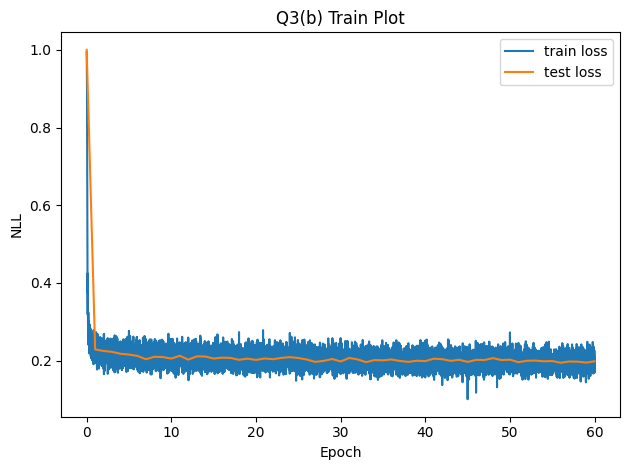

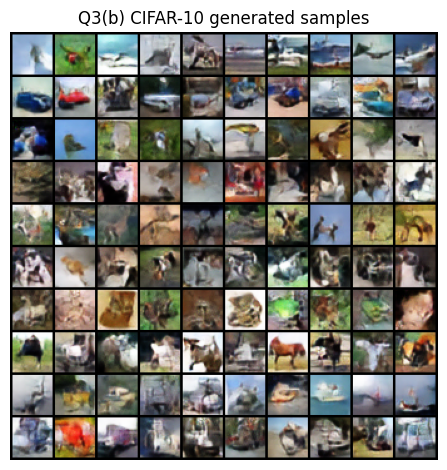

In [15]:
q3b_save_results(q3_b)

## Part 3(c) Classifier-Free Guidance [20pt]
In this part, you will implement [Classifier-Free Guidance](https://arxiv.org/abs/2207.12598) (CFG). CFG is a widely used method during diffusion model sampling to push samples towards more accurately aligning with the conditioning information (e.g. class, text caption).

Implement CFG requires a small modification to the diffusion sampling code. Given a CIFAR-10 class label, instead of using $\hat{\epsilon} = f_\theta(x_t, t, y)$ to sample, use:
$$\hat{\epsilon} = f_\theta(x_t, t, \varnothing) + w(f_\theta(x_t, t, y) - f_\theta(x_t, t, \varnothing))$$
where $w$ is a sampling hyperparameter that controls the strength of CFG. $\varnothing$ indicates the unconditional model with the class label dropped out, which your pre-trained UNet from 3(b) should support. Note that $w = 1$ recovers standard sampling.

Note: It may be expected to see worse samples (e.g. sautrated images) when CFG value is too high. Generation quality is closer to a U-shape when increasing CFG values (gets better, then worse)

In [18]:
def q3_c(vae):
    """
    vae: a pretrained vae

    Returns
    - a numpy array of size (4, 10, 10, 32, 32, 3) of samples in [0, 1] drawn from your model.
      The array represents a 4 x 10 x 10 grid of generated samples - 4 10 x 10 grid of samples
      with 4 different CFG values of w = {1.0, 3.0, 5.0, 7.5}. Each row of the 10 x 10 grid
      should contain samples of a different class. Use 512 diffusion sampling timesteps.
    """

    """ YOUR CODE HERE """
    
    # Load the trained DiT model from the 3b checkpoint
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    # Load checkpoint from q3b
    checkpoint_path = 'q3b_checkpoint.pth'
    if os.path.exists(checkpoint_path):
        print(f"Loading DiT model from {checkpoint_path}")
        checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
        
        # Get model configuration from checkpoint
        config = checkpoint['config']
        scale_factor = checkpoint['scale_factor']
        
        # Initialize DiT model
        model = DiT(config, img_size=8).to(device)  # 8x8 latent size
        model.load_state_dict(checkpoint['model_state_dict'])
        print(f"Loaded DiT model from epoch {checkpoint['epoch']}")
    else:
        raise FileNotFoundError("No q3b checkpoint found!")
    
    model.eval()
    
    # CFG values to test
    cfg_values = [1.0, 3.0, 5.0, 7.5]
    samples_all_cfg = []
    
    # Setup diffusion scheduler for sampling timesteps)
    sampling_timesteps = 1000
    sampling_scheduler = DiffusionScheduler(num_timesteps=sampling_timesteps, device=device)
    
    # Pre-generate all latent noise and class labels for batch processing
    latent_channels = config.in_channels  # Should be 4 for VAE
    latent_size = 8  # 8x8 latent size for 32x32 images
    
    for cfg_w in cfg_values:
        print(f"Generating samples with CFG w = {cfg_w}")
        
        # Generate all samples in batches for faster processing
        batch_size = 50  # Process 50 samples at once (5 classes * 10 samples)
        all_samples = []
        
        for batch_start in range(0, 100, batch_size):  # 100 total samples
            batch_end = min(batch_start + batch_size, 100)
            current_batch_size = batch_end - batch_start
            
            # Create batch of noise
            x = torch.randn(current_batch_size, latent_channels, latent_size, latent_size, device=device)
            
            # Create batch of class labels
            y_batch = []
            y_null_batch = []
            for i in range(batch_start, batch_end):
                class_label = i // 10  # 10 samples per class
                y_batch.append(class_label)
                y_null_batch.append(10)  # null token
            
            y = torch.tensor(y_batch, device=device, dtype=torch.long)
            y_null = torch.tensor(y_null_batch, device=device, dtype=torch.long)
            
            # CFG denoising loop with 512 steps
            with torch.no_grad():
                for t in reversed(range(sampling_timesteps)):
                    timestep_tensor = torch.full((current_batch_size,), t, device=device, dtype=torch.long)
                    
                    # CFG: compute both conditional and unconditional predictions
                    eps_cond = model(x, timestep_tensor, y)  # conditional
                    eps_uncond = model(x, timestep_tensor, y_null)  # unconditional
                    
                    # Apply CFG formula
                    eps = eps_uncond + cfg_w * (eps_cond - eps_uncond)
                    
                    # Denoise step using scheduler
                    x = sampling_scheduler.denoise_step(eps, t, x)
                
                # Convert back to image space
                x_scaled = x * scale_factor
                
                # VAE decode batch
                decoded_tensor = vae.decode(x_scaled)
                
                # Handle different VAE return types
                if isinstance(decoded_tensor, torch.Tensor):
                    decoded_np = decoded_tensor.cpu().numpy()
                else:
                    decoded_np = np.array(decoded_tensor)
                
                # Convert to [0, 1] range from [-1, 1]
                decoded_np = (decoded_np + 1.0) / 2.0
                decoded_np = np.clip(decoded_np, 0, 1)
                
                # Convert from (B, C, H, W) to (B, H, W, C) format
                decoded_np = decoded_np.transpose(0, 2, 3, 1)
                
                all_samples.append(decoded_np)
        
        # Concatenate all batches
        all_samples = np.concatenate(all_samples, axis=0)  # Shape: (100, 32, 32, 3)
        
        # Reshape to (10, 10, 32, 32, 3) - 10 classes, 10 samples each
        cfg_samples = all_samples.reshape(10, 10, 32, 32, 3)
        samples_all_cfg.append(cfg_samples)
        print(f"Completed CFG w = {cfg_w}, shape: {cfg_samples.shape}")
    
    # Convert to final shape (4, 10, 10, 32, 32, 3)
    samples = np.array(samples_all_cfg)
    print(f"Final samples shape: {samples.shape}")
    
    return samples

Loading DiT model from q3b_checkpoint.pth
Loaded DiT model from epoch 60
Generating samples with CFG w = 1.0


Completed CFG w = 1.0, shape: (10, 10, 32, 32, 3)
Generating samples with CFG w = 3.0
Completed CFG w = 3.0, shape: (10, 10, 32, 32, 3)
Generating samples with CFG w = 5.0
Completed CFG w = 5.0, shape: (10, 10, 32, 32, 3)
Generating samples with CFG w = 7.5
Completed CFG w = 7.5, shape: (10, 10, 32, 32, 3)
Final samples shape: (4, 10, 10, 32, 32, 3)


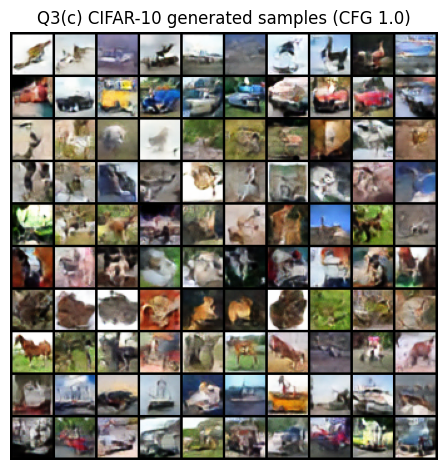

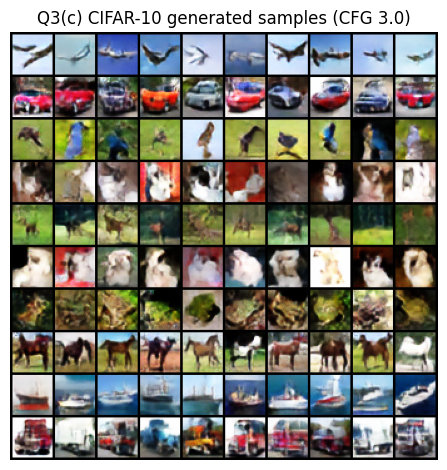

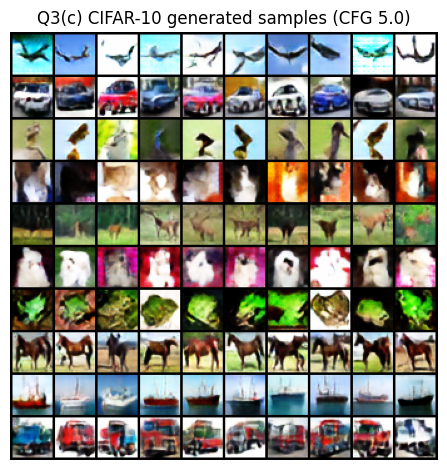

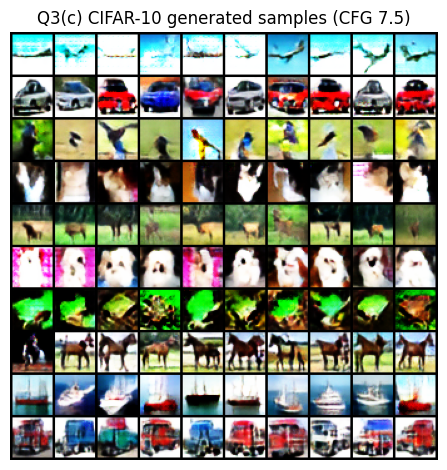

In [19]:
q3c_save_results(q3_c)